In [1]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW
import uproot
from scipy.stats import gaussian_kde

/home/iakovos-qpix/Programs/Library/MarleyTest/output/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
supernova_paths = [
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_No_Oscillations_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Fornax_Inverted_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_No_Oscillations_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Sukhbold_Inverted_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_No_Oscillations_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Nakazato_Inverted_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_No_Oscillations_1000_events.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_Normal_Hierarchy_1000_events.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Models/Bollig_Inverted_Hierarchy_1000_events.root",
]

# Labels for legend
labels = [
    # "No Oscillations - Fornax Model",
    "Normal Hierarchy - Fornax Model",
    # "Inverted Hierarchy - Fornax Model",
    # "No Oscillations - Sukhbold Model",
    "Normal Hierarchy - Sukhbold Model",
    # "Inverted Hierarchy - Sukhbold Model",
    # "No Oscillations - Nakazato Model",
    "Normal Hierarchy - Nakazato Model",
    # "Inverted Hierarchy - Nakazato Model",
    # "No Oscillations - Bollig Model",
    "Normal Hierarchy - Bollig Model",
    # "Inverted Hierarchy - Bollig Model",
]

# Colors for each dataset
colors_supernova = [
    "#0072B2",  # blue
    "#D55E00",  # reddish orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#F0E442",  # yellow
    "#56B4E9",  # light blue
]

In [44]:
background_paths = [
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Ar39.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Ar42.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Bi214.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Co60.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_K40.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_K42.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Kr85.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Pb214.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Po210.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Rn222.root",
    # "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Rn220.root",
    "/media/iakovos-qpix/aSeVertical/SuperNova Simulation/ROOT Files/SuperNova_Backgrounds/radiogenic_Rn219.root"
]


labels_background = [
    "Ar39",
    "Ar42",
    # "Bi214",
    # "Co60",
    # "K40",
    # "K42",
    # "Kr85",
    "Pb214",
    # "Po210",
    # "Rn222",
    # "Rn220",
    "Rn219"
]

colors_background = [
    "#332288",  #  1 deep blue
    "#88CCEE",  #  2 light cyan
    "#44AA99",  #  3 teal
    "#117733",  #  4 dark green
    "#999933",  #  5 olive
    "#DDCC77",  #  6 sand
    "#CC6677",  #  7 muted red
    "#882255",  #  8 wine
    "#AA4499",  #  9 magenta
    "#DDDDDD",  # 10 light gray
    "#E69F00",  # 11 orange
    "#56B4E9",  # 12 sky blue
]

In [45]:
background_data = {}
bg_events_data = {}

for path, label in zip(background_paths, labels_background):
    file = uproot.open(path)
    tree = file["G4_Photons"]

    photon_times = tree["photon_hit_t"].array(library="np")
    
    # Flatten
    all_times = np.concatenate(photon_times)

    # Clean
    mask = (all_times > 0) & (all_times < 1e10)
    clean = all_times[mask]

    # Convert ns → s
    clean_s = clean / 1e9

    print(len(clean_s), "photons in", label)

    background_data[label] = clean_s

1054351 photons in Ar39
65061 photons in Ar42
2418823 photons in Pb214
8743272 photons in Rn219


In [33]:
supernova_data = {}

for path, label in zip(supernova_paths, labels):
    file = uproot.open(path)
    tree = file["G4_Photons"]

    photon_times = tree["photon_hit_t"].array(library="np")

    # Flatten
    all_times = np.concatenate(photon_times)

    # Clean
    mask = (all_times > 0) & (all_times < 1e10)
    clean = all_times[mask]

    # Convert ns → s
    clean_s = clean / 1e9

    print(len(clean_s), "photons in", label)

    supernova_data[label] = clean_s

370590390 photons in Normal Hierarchy - Fornax Model
228782971 photons in Normal Hierarchy - Sukhbold Model
291305749 photons in Normal Hierarchy - Nakazato Model
238675520 photons in Normal Hierarchy - Bollig Model


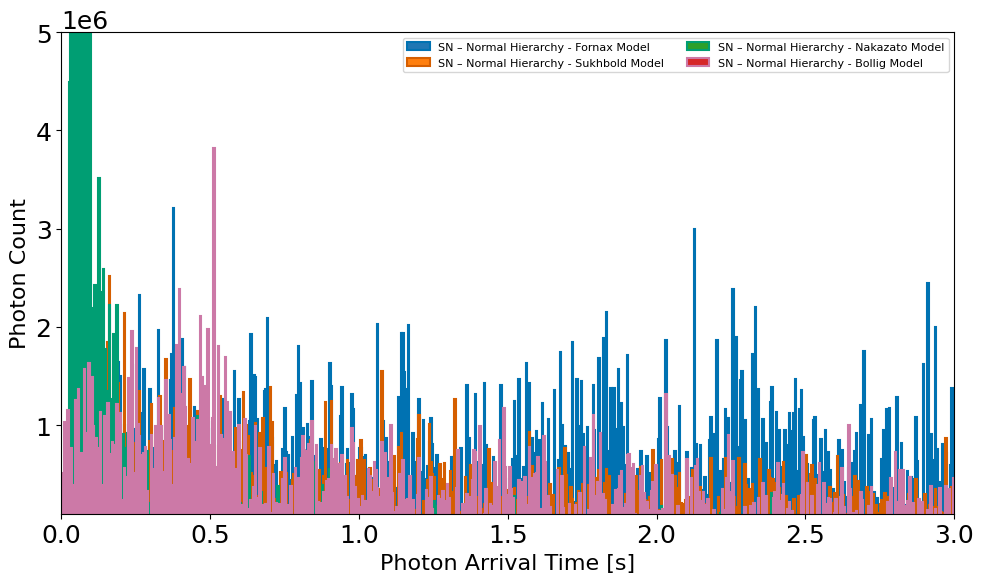

In [39]:
bin_width = 0.005
bins = np.arange(0, 6 + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(10, 6))

plt.rcParams.update({
    "font.size": 12,

    "axes.labelsize": 16,

    "xtick.labelsize": 18,

    "ytick.labelsize": 18,

    "legend.fontsize": 22,

    "legend.title_fontsize": 22

}) 

#1) Stacked background in absolute photon counts ----
# bg_counts_list = []
# for label_bg, color_bg in zip(labels_background, colors_background):
#     data_bg = background_data[label_bg]
#     counts_bg, _ = np.histogram(data_bg, bins=bins)
#     bg_counts_list.append(counts_bg)

# bottom = np.zeros_like(bg_counts_list[0], dtype=float)
# for counts_bg, label_bg, color_bg in zip(bg_counts_list, labels_background, colors_background):
#     plt.bar(
#         bin_centers,
#         counts_bg,
#         width=bin_width,
#         bottom=bottom,
#         color=color_bg,
#         alpha=0.35,
#         edgecolor="black",
#         linewidth=0.7,
#         label=label_bg,
#     )
#     bottom += counts_bg

# ---- 2) All supernova models in absolute counts (lines) ----
for label_sn, color_sn in zip(labels, colors_supernova):
    data_sn = supernova_data[label_sn]
    counts_sn, _ = np.histogram(data_sn, bins=bins)
    plt.bar(
        bin_centers,
        counts_sn,
        width=bin_width,
        # facecolor="none",      # no fill
        edgecolor=color_sn,    # colored outline
        linewidth=1.5,
        label=f"SN – {label_sn}",
    )

plt.xlabel("Photon Arrival Time [s]")
plt.ylabel(f"Photon Count")
# plt.title("Supernova Photon Signals vs Radiogenic Background")
plt.ylim(1e5, 5e6)
plt.xlim(0,3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

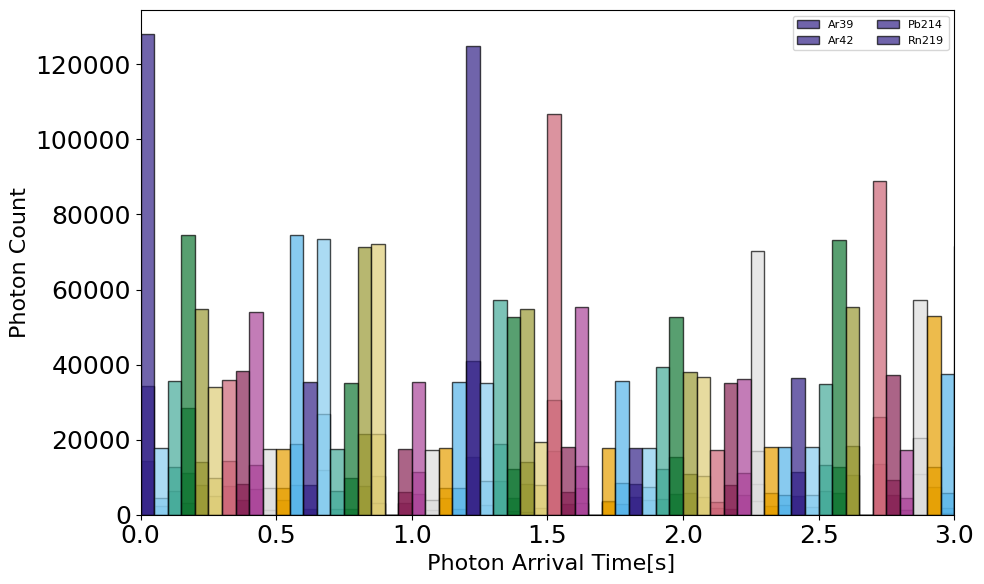

In [47]:
bin_width = 0.05
bins = np.arange(0, 6 + bin_width, bin_width)

plt.figure(figsize=(10, 6))

plt.rcParams.update({
    "font.size": 12,

    "axes.labelsize": 16,

    "xtick.labelsize": 18,

    "ytick.labelsize": 18,

    "legend.fontsize": 22,

    "legend.title_fontsize": 22

}) 

for label_bg, color in zip(labels_background, colors_background):
    data_bg = background_data[label_bg]

    counts_bg, bin_edges  = np.histogram(data_bg, bins=bins)

    # if counts_bg.max() > 0:
    #     counts_bg_norm = counts_bg / counts_bg.max()
    # else:
    #     counts_bg_norm = counts_bg

    bin_centers_bg = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    plt.bar(
        bin_centers_bg,
        counts_bg,
        width=bin_width,
        color=colors_background,
        alpha=0.7,
        edgecolor="black",
        linewidth=1.0,
        label=label_bg,
    )

plt.xlabel(" Photon Arrival Time[s]")
plt.ylabel("Photon Count")
# plt.ylim(0,2e4)
# plt.yscale("log")
plt.xlim(0,3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()